In [2]:
import os
from ram.dataset.kinematics import forward_kinematics, inverse_kinematics
from ram.dataset.self_collision import get_capsules, LINK_RADIUS
from ram.dataset.self_collision import collision_check


from plotly.subplots import make_subplots
from paper_archive.utils import get_cylinder_mesh, get_sphere_mesh
import plotly.graph_objects as go
import numpy as np
import plotly.io as pio

import pickle
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tabulate import tabulate
from pathlib import Path

In [3]:
mean_pose_error_base, lower_pose_error_base, upper_pose_error_base = pickle.load(open(Path.cwd() / "data"/ "pose_error_base.pkl", "rb"))
mean_pose_error_ours, lower_pose_error_ours, upper_pose_error_ours = pickle.load(open(Path.cwd() / "data"/ "pose_error_ours.pkl", "rb"))
mean_self_collisions_base, lower_self_collisions_base, upper_self_collisions_base = (
    pickle.load(open(Path.cwd() / "data"/ "self_collisions_base.pkl", "rb")))
mean_self_collisions_ours, lower_self_collisions_ours, upper_self_collisions_ours = (
    pickle.load(open(Path.cwd() / "data"/ "self_collisions_ours.pkl", "rb")))
mean_base_runtime, lower_base_runtime, upper_base_runtime = pickle.load(open(Path.cwd() / "data"/ "base_runtime.pkl", "rb"))
mean_ours_runtime, lower_ours_runtime, upper_ours_runtime = pickle.load(open(Path.cwd() / "data"/ "ours_runtime.pkl", "rb"))

In [4]:
mean_pose_error_base[-1] / mean_pose_error_base[0]

np.float32(0.31394967)

In [5]:
mean_pose_error_ours[-1] / mean_pose_error_ours[0]

np.float32(0.22088763)

In [30]:
 mean_self_collisions_base[-1] / 1000, mean_self_collisions_base[0]

(np.float64(0.055299999999999995), np.float64(0.16388))

In [31]:
 mean_self_collisions_ours[-1]/ 1000 , mean_self_collisions_ours[0] / 1000

(np.float64(0.05962), np.float64(0.16363))

In [2]:
data = [
    [
        "Baseline",
        f"{mean_pose_error_base[-1]:.4f} ({lower_pose_error_base[-1]:.4f}, {upper_pose_error_base[-1]:.4f})",
        f"{mean_self_collisions_base[-1]:.4f} ({lower_self_collisions_base[-1]:.4f}, {upper_self_collisions_base[-1]:.4f})"
    ],
    [
        "Ours",
        f"{mean_pose_error_ours[-1]:.4f} ({lower_pose_error_ours[-1]:.4f}, {upper_pose_error_ours[-1]:.4f})",
        f"{mean_self_collisions_ours[-1]:.4f} ({lower_self_collisions_ours[-1]:.4f}, {upper_self_collisions_ours[-1]:.4f})"
    ]
]

headers = ["Method", "Final Pose Error (Mean [CI])", "Final Self Collisions (Mean [CI])"]

print(tabulate(data, headers=headers, tablefmt="github"))

| Method   | Final Pose Error (Mean [CI])   | Final Self Collisions (Mean [CI])   |
|----------|--------------------------------|-------------------------------------|
| Baseline | 0.0167 (0.0134, 0.0203)        | 55.3000 (41.8897, 70.6208)          |
| Ours     | 0.0117 (0.0081, 0.0164)        | 59.6200 (21.2075, 109.7530)         |


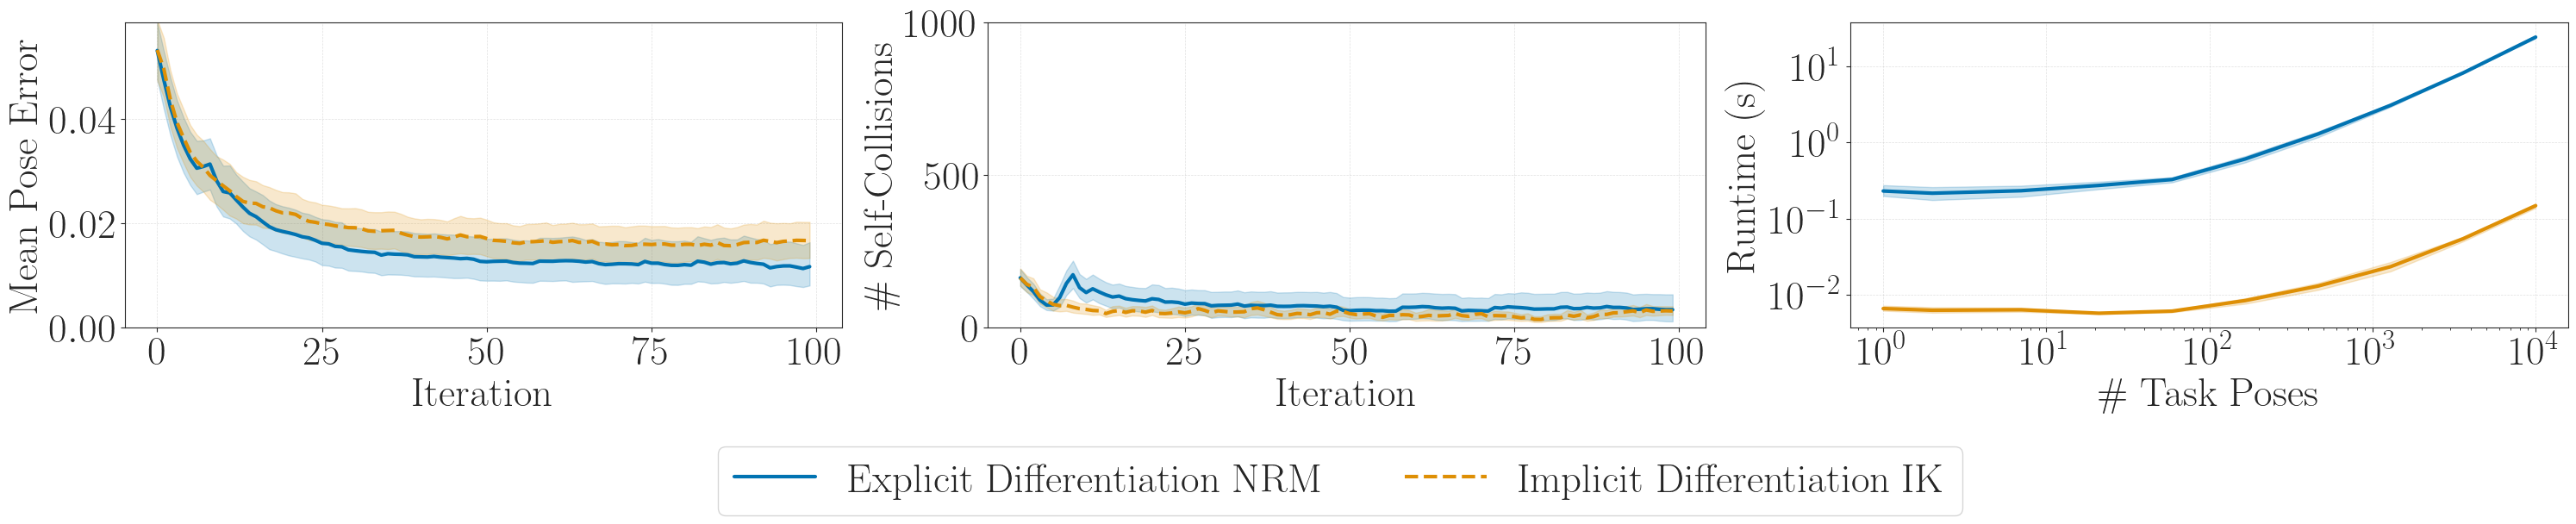

In [89]:
sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "text.latex.preamble": r"\usepackage{amsmath}",

    "axes.labelsize": 34,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "legend.fontsize": 34,
    "axes.titlesize": 34,
    "lines.linewidth": 3,
})


fig, ax = plt.subplots(1, 3, figsize=(30, 5))
colors = sns.color_palette("colorblind", 4)
x = torch.arange(0, 100)
ax[0].plot(x, mean_pose_error_ours, label=r"$\text{Explicit Differentiation RAM}$", color=colors[0])
ax[0].fill_between(x, lower_pose_error_ours, upper_pose_error_ours, color=colors[0], alpha=0.2)
ax[0].plot(x, mean_pose_error_base, label=r"$\text{Implicit Differentiation IK}$", color=colors[1], linestyle="dashed")
ax[0].fill_between(x, lower_pose_error_base, upper_pose_error_base, color=colors[1], alpha=0.2)

ax[0].set_ylabel(r"$\text{Mean Pose Error}$")
ax[0].set_xlabel(r"$\text{Iteration}$")
ax[0].set_ylim(0.0, mean_pose_error_base.max()*1.1)

ax[1].plot(x, mean_self_collisions_ours, label=r"$\text{Explicit Differentiation RAM}$", color=colors[0])
ax[1].fill_between(x, lower_self_collisions_ours, upper_self_collisions_ours, color=colors[0], alpha=0.2)
ax[1].plot(x, mean_self_collisions_base, label=r"$\text{Implicit Differentiation IK}$", color=colors[1], linestyle="dashed")
ax[1].fill_between(x, lower_self_collisions_base, upper_self_collisions_base, color=colors[1], alpha=0.2)

ax[1].set_ylim(-0.1, 1000 + 0.1)
ax[1].set_ylabel(r"$\text{\# Self-Collisions}$")
ax[1].set_xlabel(r"$\text{Iteration}$")

x = torch.logspace(0, 4, 10).int()
per_iteration = 100
ax[2].plot(x, mean_base_runtime/per_iteration, label=r"$\text{Implicit Differentiation IK}$", color=colors[0])
ax[2].fill_between(x, lower_base_runtime/per_iteration, upper_base_runtime/per_iteration, color=colors[0], alpha=0.2)
ax[2].plot(x, mean_ours_runtime/per_iteration, label=r"$\text{Explicit Differentiation RAM}$", color=colors[1])
ax[2].fill_between(x, lower_ours_runtime/per_iteration, upper_ours_runtime/per_iteration, color=colors[1], alpha=0.2)
ax[2].set_ylabel(r"$\text{Runtime (s)}$")
ax[2].set_xlabel(r"$\text{\# Task Poses}$")
ax[2].set_yscale("log")
ax[2].set_xscale("log")
ax[2].yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=4))
ax[2].yaxis.set_minor_formatter(ticker.LogFormatterExponent())

for i in range(len(ax)):
    ax[i].grid(True, linestyle='--', alpha=0.6)

handles, labels = ax[0].get_legend_handles_labels()

# Add the legend to the FIGURE, not the AXES
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.52, 0.0)
)

plt.tight_layout()
plt.savefig("design_optimisation.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [32]:


pio.renderers.default = "browser"
save_dir = Path(os.getcwd()).parent / "rq3_design_optimisation" / "data" / "ours"
morph = pickle.load(open(save_dir / "morph.pkl", "rb"))[-1]
initial_morph = pickle.load(open(save_dir / "initial_morph.pkl", "rb")).cpu()
task = pickle.load(open(save_dir / "task.pkl", "rb")).cpu()
save_dir = Path(os.getcwd()).parent / "rq3_design_optimisation" / "data" / "base"
base_morph = pickle.load(open(save_dir / "morph.pkl", "rb"))[-1]

In [80]:
def qualitative_design_plot(morph, task, name):
    joints, manipulability = inverse_kinematics(morph, task)
    poses = forward_kinematics(morph.unsqueeze(0).expand(1000, -1, -1), joints)
    self_collision = collision_check(morph.unsqueeze(0).expand(1000, -1, -1), poses)
    poses = poses[:, -1]

    s_all, e_all = get_capsules(morph, forward_kinematics(morph, torch.zeros(morph.shape[0], 1)))

    palette = sns.color_palette("colorblind", 4)
    color_true = palette[2]
    color_false = palette[3]

    COLOR_JOINT = f"rgb{tuple((255 * np.array((0.2, 0.2, 0.2))).astype(int).tolist())}"  # Dark Grey for motors
    COLOR_BASE = f"rgb{tuple((255 * np.array((0.1, 0.4, 0.8))).astype(int).tolist())}"  # Blue for base
    COLOR_LINKS = f"rgb{tuple((255 * np.array((0.8, 0.8, 0.8))).astype(int).tolist())}"  # Light Grey

    COLOR_T = f"rgb{tuple((255 * np.array(color_true)).astype(int).tolist())}"  # Dark Grey for motors
    COLOR_F = f"rgb{tuple((255 * np.array(color_false)).astype(int).tolist())}"  # Blue for base

    fig = make_subplots(
        rows=1, cols=1,
        specs=[[{"type": "scene"}]],
        horizontal_spacing=0.01,
        vertical_spacing=0.05,
    )

    a = 0.1
    d = 0.2

    all_distances = torch.norm(poses[:, :3, 3] - task[:, :3, 3], dim=-1)
    color_values = torch.clamp((all_distances - 1e-4) / (0.1 - 1e-4), 0.0, 1.0)
    color_values[self_collision] = 1.0
    line_colors = np.repeat(color_values.numpy(), 5)

    GRADIENT_SCALE = [
        [0.0, COLOR_T],  # Solid Green
        [1.0, COLOR_F]  # Faded Red
    ]
    for i, p in enumerate([task, poses]):
        origins = p[:, :3, 3]
        z_axes = p[:, :3, 2]
        x_axes = p[:, :3, 0]
        # Calculate start points
        z_ends = origins - (z_axes * 0.1 * (d / (a + d)))
        x_ends = z_ends - (x_axes * 0.1 * (a / (a + d)))

        # Build line segments: [start, origin, NaN]
        l_shapes = torch.stack([z_ends, origins, z_ends, x_ends], dim=1)
        nans = torch.full((l_shapes.shape[0], 1, 3), float('nan'))
        with_nans = torch.cat([l_shapes, nans], dim=1)

        plot_data = with_nans.reshape(-1, 3).numpy()

        if i == 0:
            line_style = dict(color=COLOR_BASE, width=7)
            marker_style = dict(size=5, color=COLOR_BASE, opacity=0.1)
        else:
            line_style = dict(
                color=line_colors, colorscale=GRADIENT_SCALE,
                cmin=0.0, cmax=1.0, width=7
            )
            marker_style = dict(
                color=color_values, colorscale=GRADIENT_SCALE,
                cmin=0.0, cmax=1.0, size=5, opacity=0.3
            )

        fig.add_trace(
            go.Scatter3d(
                x=plot_data[:, 0],
                y=plot_data[:, 1],
                z=plot_data[:, 2],
                mode='lines',
                opacity=0.1 if i == 0 else 0.3,
                line=line_style,
                hoverinfo='skip'
            ), row=1, col=1)
        fig.add_trace(
            go.Scatter3d(
                x=origins[:, 0],
                y=origins[:, 1],
                z=origins[:, 2],
                mode='markers',
                marker=marker_style,
                hoverinfo='skip'
            ), row=1, col=1)

    base = 0
    for i in range(len(s_all)):
        if torch.norm(s_all[i] - e_all[i]) < 1e-6:
            continue

        cx, cy, cz = get_cylinder_mesh(s_all[i].cpu(), e_all[i].cpu(), radius=LINK_RADIUS, resolution=15)
        fig.add_trace(
            go.Surface(
                x=cx, y=cy, z=cz,
                showscale=False,
                surfacecolor=torch.zeros_like(cx),
                colorscale=[[0, COLOR_LINKS], [1, COLOR_LINKS]],
                lighting=dict(ambient=0.6, diffuse=0.8, specular=0.2, roughness=0.5),
                hoverinfo='skip'
            ), row=1, col=1)
        sx, sy, sz = get_sphere_mesh(s_all[i], radius=LINK_RADIUS * 1.1, resolution=15)
        fig.add_trace(
            go.Surface(
                x=sx, y=sy, z=sz,
                showscale=False,
                surfacecolor=torch.zeros_like(sx),
                colorscale=[[0, COLOR_JOINT if base != 0 else COLOR_BASE],
                            [1, COLOR_JOINT if base != 0 else COLOR_BASE]],
                lighting=dict(ambient=0.6, diffuse=0.8, specular=0.2, roughness=0.5),
                hoverinfo='skip'
            ), row=1, col=1)
        base += 1
    sx, sy, sz = get_sphere_mesh(e_all[-1], radius=LINK_RADIUS * 1.1, resolution=15)
    fig.add_trace(
        go.Surface(
            x=sx, y=sy, z=sz,
            showscale=False,
            surfacecolor=torch.zeros_like(sx),
            colorscale=[[0, COLOR_LINKS],
                        [1, COLOR_LINKS]],
            lighting=dict(ambient=0.6, diffuse=0.8, specular=0.2, roughness=0.5),
            hoverinfo='skip'
        ), row=1, col=1)

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0, pad=0),
        template="plotly_white",
        # CRITICAL: Keep it transparent
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        showlegend=False,
        scene=dict(
            camera=dict(
                eye=dict(x=0.65, y=0.65, z=0.65)
            ),
            domain=dict(x=[0, 1], y=[0, 1]),  # Preserved max domain
            xaxis=dict(visible=False, showbackground=False),
            yaxis=dict(visible=False, showbackground=False),
            zaxis=dict(visible=False, showbackground=False),
            aspectmode='data',
            bgcolor='rgba(0,0,0,0)'  # Transparent scene
        ),
        scene_aspectratio=dict(x=1, y=1, z=1)
    )
    pio.write_image(fig, f"{name}.png", width=1100, height=1100, scale=1)
    fig.show()

In [81]:
qualitative_design_plot(initial_morph, task, "morph_initial")

In [82]:
qualitative_design_plot(morph, task, "morph_ours")

In [83]:
qualitative_design_plot(base_morph, task, "morph_base")